# Notebook 3: Pemodelan dan Evaluasi Akhir

Selamat datang di tahap paling akhir dari sistem OCR kita. Di sini kita akan merangkai seluruh fitur yang telah diekstrak pada tahap sebelumnya untuk melatih "Otak" utama dari sistem.

Notebook ini bertugas melatih tiga model secara berurutan secara ketat dan kebal kebocoran data: Origin Classifier (penentu negara), Triage Classifier (penentu kualitas), dan Field Classifier (penentu jenis teks). Di akhir notebook, kita akan bisa melihat skor akhir yang menentukan apakah sistem ini siap dipakai di dunia nyata atau belum.

## Inisialisasi dan Impor Modul Dasar
Blok ini bertugas mengimpor semua pustaka eksternal dan menetapkan variabel jalur folder.
Kita mengatur ini di awal agar sisa kode bisa fokus pada logika inti tanpa perlu berulang kali mengatur jalur file dan pengaturan dasar.

In [17]:
import os
import re
import cv2
import json
import warnings
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import Levenshtein as lev
import lightgbm as lgb
import shap
import optuna
from functools import partial
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})

DATASET_DIR   = 'dataset'
IMG_DIR       = os.path.join(DATASET_DIR, 'images')
CROPPED_DIR   = os.path.join(DATASET_DIR, 'cropped_images_lib')  # matches NB2 output directory
MASTER_PATH   = os.path.join(DATASET_DIR, 'master_features.csv')
SEGMENTS_PATH = os.path.join(DATASET_DIR, 'ocr_segments_features.csv')
FOLD_PATH     = os.path.join(DATASET_DIR, 'fold_indices.pkl')

FEATURE_COLS = [
    'y_rel_scaled', 'x_rel_scaled', 'width_rel_scaled',
    'text_len', 'word_count',
    'ocr_conf', 'alpha_ratio', 'digit_ratio', 'is_all_caps',
    'has_date_pattern', 'has_address_kw', 'has_state_kw',
    'has_postcode', 'has_bin_binti', 'line_rank_norm',
    'doc_origin_encoded',
]

TRIAGE_FEATURES = [
    'crop_blur_score_log', 'crop_brightness', 'crop_contrast',
    'crop_edge_density', 'crop_dark_pixel_ratio', 'skew_angle', 'quality_pc1',
]

LABEL_MAP     = {'other': 0, 'name': 1, 'birth_date': 2, 'address': 3}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
COLOR_MAP = {
    'name':       (0,   0, 255),
    'birth_date': (255, 0,   0),
    'address':    (0, 255,   0),
    'other':      (128, 128, 128),
}

print('Setup selesai.')

Setup selesai.


## Memuat Data Utama
Blok ini mengambil data csv dan indeks pembagian pelatihan yang sudah dibuat dari tahap sebelumnya.
Kita menggunakan pembagian data pelatihan yang dikunci di awal supaya pengujian kita adil dan tidak ada data identitas yang bocor.

In [18]:
df          = pd.read_csv(MASTER_PATH)
df_segments = pd.read_csv(SEGMENTS_PATH)

with open(FOLD_PATH, 'rb') as f:
    folds = pickle.load(f)

print(f"Master df     : {len(df)} gambar")
print(f"Segmen        : {len(df_segments)} segmen teks")
print(f"Jumlah fold   : {len(folds)}")

Master df     : 632 gambar
Segmen        : 11405 segmen teks
Jumlah fold   : 5


## Mengatur Fungsi Metrik Evaluasi Teks
Blok ini merumuskan kalkulator akurasi teks seperti CER WER dan Token F1.
Kita memakai rumus matematis ini karena mencocokkan kemiripan tulisan identitas jauh lebih masuk akal ketimbang menuntut akurasi huruf sempurna seratus persen.

In [19]:
def compute_cer(hyp: str, ref: str) -> float:
    ref_str = str(ref).strip().lower()
    hyp_str = str(hyp).strip().lower()
    if len(ref_str) == 0:
        return 0.0 if len(hyp_str) == 0 else 1.0
    return lev.distance(hyp_str, ref_str) / len(ref_str)

def compute_wer(hyp: str, ref: str) -> float:
    ref_words = str(ref).strip().lower().split()
    hyp_words = str(hyp).strip().lower().split()
    if len(ref_words) == 0:
        return 0.0 if len(hyp_words) == 0 else 1.0
    return lev.distance(' '.join(hyp_words), ' '.join(ref_words)) / len(ref_words)

def compute_f1_token(hyp: str, ref: str) -> float:
    ref_set = set(str(ref).strip().lower().split())
    hyp_set = set(str(hyp).strip().lower().split())
    if not ref_set and not hyp_set:
        return 1.0
    if not ref_set or not hyp_set:
        return 0.0
    tp        = len(ref_set & hyp_set)
    precision = tp / len(hyp_set)
    recall    = tp / len(ref_set)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def exact_accuracy(hyp: str, ref: str) -> float:
    return float(str(hyp).strip().lower() == str(ref).strip().lower())

## Membersihkan dan Validasi Teks
Blok ini menghapus simbol aneh, singkatan alamat, dan memastikan tanggal lahir masuk akal.
Kita melakukan tahap ini supaya kecacatan kecil pembacaan bisa diperbaiki otomatis sehingga manusia tidak perlu turun tangan.

In [20]:
ADDR_ABBREV = {
    r'\bJLN\b': 'JALAN', r'\bLRG\b': 'LORONG', r'\bKG\b': 'KAMPUNG',
    r'\bTMN\b': 'TAMAN', r'\bPKR\b': 'PERAK',
}

def _normalize_name(text: str) -> str:
    text = text.upper().strip()
    for noise in ['NAMA:', 'NAME:', 'NAMA', 'NAME', 'PENUH', 'FULL']:
        text = text.replace(noise, '')
    text = re.sub(r'[^A-Z /\-]', ' ', text)
    noise_words = ['WARGANEGARA', 'MALAYSIA', 'LELAKI', 'PEREMPUAN', 'ISLAM', 'MYKAD', 'KAD', 'PENGENALAN']
    for noise in noise_words:
        text = re.sub(rf'\b{noise}\b', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def _normalize_date(text: str) -> str:
    text_clean = re.sub(r'[^0-9A-Z<]', '', text.upper())

    m_mrz = re.search(r'[A-Z<]{3}(\d{2})(\d{2})(\d{2})\d[A-Z<]', text_clean)
    if m_mrz:
        yy, mm, dd = m_mrz.groups()
        if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31:
            yyyy = "19" + yy if int(yy) > 25 else "20" + yy
            return f"{yyyy}-{mm}-{dd}"

    m_ic = re.search(r'(\d{2})(\d{2})(\d{2})\d{2}\d{4}', text_clean)
    if m_ic:
        yy, mm, dd = m_ic.groups()
        if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31:
            yyyy = "19" + yy if int(yy) > 25 else "20" + yy
            return f"{yyyy}-{mm}-{dd}"

    m = re.search(r'(\d{4})-(\d{2})-(\d{2})', text)
    if m: return f"{m.group(1)}-{m.group(2)}-{m.group(3)}"
    m = re.search(r'(\d{2})/(\d{2})/(\d{4})', text)
    if m: return f"{m.group(3)}-{m.group(2)}-{m.group(1)}"

    m_any = re.search(r'(\d{2})(\d{2})(\d{2})', text_clean)
    if m_any:
        yy, mm, dd = m_any.groups()
        if 1 <= int(mm) <= 12 and 1 <= int(dd) <= 31:
            yyyy = "19" + yy if int(yy) > 25 else "20" + yy
            return f"{yyyy}-{mm}-{dd}"

    return text.strip()

def _normalize_address(text: str) -> str:
    text = text.upper().strip()
    for noise in ['ALAMAT:', 'ADDRESS:', 'ALAMAT', 'ADDRESS']:
        text = text.replace(noise, '')
    for abbr, full in ADDR_ABBREV.items():
        text = re.sub(abbr, full, text)
    return re.sub(r'\s+', ' ', text).strip()

def validate_name(text: str) -> tuple:
    if not text or len(text) < 2:
        return False, 'EMPTY'
    if any(c.isdigit() for c in text):
        return False, 'CONTAINS_DIGIT'
    if len(text) > 100:
        return False, 'TOO_LONG'
    return True, 'OK'

def validate_date(text: str) -> tuple:
    if not text:
        return False, 'EMPTY'
    m = re.match(r'^(\d{4})(?:-(\d{2})-(\d{2}))?$', text)
    if not m:
        return False, 'BAD_FORMAT'
    year = int(m.group(1))
    if not (1900 <= year <= 2015):
        return False, f'YEAR_OUT_OF_RANGE:{year}'
    if m.group(2):
        month, day = int(m.group(2)), int(m.group(3))
        if not (1 <= month <= 12):
            return False, f'BAD_MONTH:{month}'
        if not (1 <= day <= 31):
            return False, f'BAD_DAY:{day}'
    return True, 'OK'

def assemble_field(segs_df: pd.DataFrame, label: str, is_malaysia: bool) -> tuple:
    subset = segs_df[segs_df['pred_label_str'] == label].copy()
    if subset.empty:
        return '', 0.0

    # Drop low-confidence segments to filter out signatures, watermarks, and OCR noise.
    subset = subset[subset['ocr_conf'] >= CONF_FLOOR]
    if subset.empty:
        return '', 0.0

    # Deduplicate overlapping bounding boxes: same word shouldn't be concatenated twice.
    subset = subset.copy()
    subset['_y_rounded'] = subset['y_rel_scaled'].round(2)
    subset['_x_rounded'] = subset['x_rel_scaled'].round(2)
    subset = subset.drop_duplicates(subset=['_y_rounded', '_x_rounded'])
    subset = subset.drop(columns=['_y_rounded', '_x_rounded'])

    avg_conf = float(subset['ocr_conf'].mean())

    if label in ['name', 'address']:
        subset = subset.sort_values('y_rel_scaled')
        line_ids = []
        current_line_id = 0
        last_y = -100
        for y in subset['y_rel_scaled']:
            if y - last_y > 0.02:
                current_line_id += 1
                last_y = y
            line_ids.append(current_line_id)
        subset['line_id'] = line_ids
        subset = subset.sort_values(['line_id', 'x_rel_scaled'])

        if label == 'name':
            return _normalize_name(' '.join(subset['text'].astype(str))), avg_conf
        else:
            if not is_malaysia:
                return '', 0.0
            return _normalize_address(' '.join(subset['text'].astype(str))), avg_conf

    if label == 'birth_date':
        best_row = subset.loc[subset['ocr_conf'].idxmax()]
        return _normalize_date(str(best_row['text'])), float(best_row['ocr_conf'])

    return '', 0.0

CONF_AUTO_APPROVE = 0.75
CONF_HUMAN_REVIEW = 0.45
# CONF_FLOOR: minimum OCR confidence for a segment to be included in field assembly.
# Calibrated from triage EDA (Section 9). Lower to 0.80 if evaluation shows over-rejection.
CONF_FLOOR        = 0.85

def route_decision(name_conf: float, dob_conf: float, name_valid: bool,
                   dob_valid: bool, is_malaysia: bool, addr_conf: float) -> str:
    if not name_valid or not dob_valid:
        return 'HUMAN_REVIEW'
    min_conf = min(name_conf, dob_conf)
    if is_malaysia:
        min_conf = min(min_conf, addr_conf)
    if min_conf >= CONF_AUTO_APPROVE:
        return 'AUTO_APPROVE'
    return 'HUMAN_REVIEW'

## Melatih Model dan Mengukur Akurasi
Blok ini melatih detektor negara, pengukur buram, serta penentu kategori teks secara ketat dan terpisah untuk setiap bagian data pelatihan.
Kita memakai skema Cross Validation supaya akurasi yang tercatat benar benar mencerminkan kemampuannya saat dihadapkan pada KTP baru di dunia nyata yang belum pernah ia temui.

In [21]:
all_fold_metrics = []
origin_clf_metrics = []
triage_metrics = []
# Declared outside the fold loop so all 632 images accumulate.
# Each image appears in exactly one test fold, so there are no duplicates.
all_predictions_log = []

for fold_idx, fold_dict in enumerate(folds):
    train_idx, test_idx = fold_dict['train'], fold_dict['test']
    print(f"\n{'='*55}")
    print(f"FOLD {fold_idx + 1} / {len(folds)}")

    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    train_filenames = set(df_train['filename'])
    test_filenames  = set(df_test['filename'])

    df_seg_train = df_segments[df_segments['filename'].isin(train_filenames)].copy()
    df_seg_test  = df_segments[df_segments['filename'].isin(test_filenames)].copy()

    train_texts = df_seg_train.groupby('filename')['text'].apply(lambda x: ' '.join([str(v).lower() for v in x]))
    y_origin_train = df_train.set_index('filename').loc[train_texts.index, 'doc_origin_encoded_target'] == 1

    origin_clf = make_pipeline(TfidfVectorizer(max_features=300), LogisticRegression(random_state=42, class_weight='balanced'))
    origin_clf.fit(train_texts, y_origin_train)

    train_origin_preds = origin_clf.predict(train_texts)
    origin_pred_dict_train = dict(zip(train_texts.index, train_origin_preds))
    df_seg_train['doc_origin_encoded'] = df_seg_train['filename'].map(origin_pred_dict_train).astype(int)

    test_texts = df_seg_test.groupby('filename')['text'].apply(lambda x: ' '.join([str(v).lower() for v in x]))
    y_origin_test = df_test.set_index('filename').loc[test_texts.index, 'doc_origin_encoded_target'] == 1

    test_origin_preds = origin_clf.predict(test_texts)
    origin_pred_dict_test = dict(zip(test_texts.index, test_origin_preds))
    df_seg_test['doc_origin_encoded'] = df_seg_test['filename'].map(origin_pred_dict_test).fillna(1).astype(int)

    precision_org, recall_org, f1_org, _ = precision_recall_fscore_support(y_origin_test, test_origin_preds, average='binary')
    origin_clf_metrics.append({'fold': fold_idx, 'precision': precision_org, 'recall': recall_org, 'f1': f1_org})

    # Hitung is_readable dinamis berdasarkan threshold fold ini
    triage_train_data = []
    for fname in df_train['filename']:
        group = df_seg_train[df_seg_train['filename'] == fname]
        avg_conf = float(df_train[df_train['filename'] == fname]['avg_ocr_conf'].iloc[0])
        row_gt = df_train[df_train['filename'] == fname].iloc[0]
        full_ocr_text = ' '.join([str(x) for x in group['text']]).upper().strip()
        ref_tokens = [t for t in str(row_gt['name']).strip().upper().split() if len(t) > 2]
        hyp_tokens = full_ocr_text.split()

        matched_count = 0
        if ref_tokens:
            for r_tok in ref_tokens:
                for h_tok in hyp_tokens:
                    max_edits = 1 if len(r_tok) >= 4 else 0
                    if lev.distance(r_tok, h_tok) <= max_edits:
                        matched_count += 1
                        break
            recall = matched_count / len(ref_tokens)
        else:
            recall = 1.0
        triage_train_data.append({'filename': fname, 'avg_conf': avg_conf, 'recall': recall})

    df_triage_curve_train = pd.DataFrame(triage_train_data)
    conf_bins = np.linspace(0, 1, 11)
    df_triage_curve_train['conf_bin'] = pd.cut(df_triage_curve_train['avg_conf'], bins=conf_bins)
    median_recall_per_bin = df_triage_curve_train.groupby('conf_bin')['recall'].median()
    threshold_conf = None
    for interval, med_r in median_recall_per_bin.items():
        if pd.notna(med_r) and med_r >= 0.8:
            threshold_conf = interval.left
            break

    if threshold_conf is None:
        fallback_threshold = 0.85
        warnings.warn(
            "Triage WARNING: Tidak ada bin keyakinan yang memenuhi syarat median_recall >= 0.8. "
            f"Menggunakan fallback threshold: {fallback_threshold}"
        )
        threshold_conf = fallback_threshold

    df_triage_train = df_train.copy()
    df_triage_train['is_readable'] = (df_triage_train['avg_ocr_conf'] >= threshold_conf).astype(int)

    avail_triage_feat = [f for f in TRIAGE_FEATURES if f in df_triage_train.columns]

    X_t = df_triage_train[avail_triage_feat].fillna(0)
    y_t = df_triage_train['is_readable']

    triage_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    triage_clf.fit(X_t, y_t)

    df_triage_test = df_test.copy()
    df_triage_test['is_readable'] = (df_triage_test['avg_ocr_conf'] >= threshold_conf).astype(int)
    X_t_test = df_triage_test[avail_triage_feat].fillna(0)
    y_t_test = df_triage_test['is_readable']
    y_t_pred = triage_clf.predict(X_t_test)

    frr = np.sum((y_t_test == 1) & (y_t_pred == 0)) / max(np.sum(y_t_test == 1), 1)
    far = np.sum((y_t_test == 0) & (y_t_pred == 1)) / max(np.sum(y_t_test == 0), 1)
    triage_metrics.append({'fold': fold_idx, 'frr': frr, 'far': far})

    avail_seg_feat = [f for f in FEATURE_COLS if f in df_seg_train.columns]
    X_seg_train    = df_seg_train[avail_seg_feat].fillna(0)
    y_seg_train    = df_seg_train['label'].map(LABEL_MAP)

    def optuna_objective(trial, X, y):
        params = {
            'objective': 'multiclass',
            'num_class': 4,
            'class_weight': 'balanced',
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 40),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 30),
            'random_state': 42,
            'verbose': -1
        }
        from sklearn.model_selection import StratifiedKFold
        from sklearn.metrics import f1_score
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = []
        for tr_idx, val_idx in cv.split(X, y):
            clf = lgb.LGBMClassifier(**params)
            clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            preds = clf.predict(X.iloc[val_idx])
            scores.append(f1_score(y.iloc[val_idx], preds, average='macro'))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study.optimize(lambda trial: optuna_objective(trial, X_seg_train, y_seg_train), n_trials=5)

    best_params = study.best_params
    best_params.update({'objective': 'multiclass', 'num_class': 4, 'class_weight': 'balanced', 'random_state': 42, 'verbose': -1})

    field_clf = lgb.LGBMClassifier(**best_params)
    field_clf.fit(X_seg_train, y_seg_train)

    X_seg_test  = df_seg_test[avail_seg_feat].fillna(0)
    y_pred_test = field_clf.predict(X_seg_test)
    df_seg_test = df_seg_test.copy()
    df_seg_test['pred_label_str'] = [INV_LABEL_MAP[p] for p in y_pred_test]

    fold_metrics     = []
    predictions_log  = []  # Per-fold buffer; extended into all_predictions_log at fold end
    for _, row in df_test.iterrows():
        fname       = row['filename']
        is_malaysia = bool(origin_pred_dict_test.get(fname, True))
        segs        = df_seg_test[df_seg_test['filename'] == fname]

        triage_test_row = df_test[df_test['filename'] == fname]
        triage_feats    = triage_test_row[avail_triage_feat].fillna(0) if avail_triage_feat else None
        triage_pred     = 1
        if triage_feats is not None and len(triage_feats) > 0:
            triage_pred = triage_clf.predict(triage_feats)[0]

        if triage_pred == 0:
            fold_metrics.append({
                'fold': fold_idx, 'filename': fname,
                'triage_rejected': True, 'routing': 'REJECT',
                'predicted_origin': 'MALAYSIA' if is_malaysia else 'LUAR_NEGERI',
                'name_conf': 0.0, 'dob_conf': 0.0, 'addr_conf': 0.0,
                'cer_name': np.nan, 'wer_name': np.nan, 'f1_name': np.nan, 'exact_name': np.nan,
                'cer_dob': np.nan,  'exact_dob': np.nan,
                'cer_addr': np.nan, 'wer_addr': np.nan, 'f1_addr': np.nan, 'exact_addr': np.nan,
            })
            predictions_log.append({
                'filename': fname, 'routing': 'REJECT',
                'pred_name': '[TRIAGE REJECTED]', 'gt_name': str(row['name']),
                'pred_dob':  '[TRIAGE REJECTED]', 'gt_dob':  str(row['birth_date']),
                'pred_addr': '[TRIAGE REJECTED]', 'gt_addr': str(row.get('address', '')),
            })
            continue

        pred_name, name_conf = assemble_field(segs, 'name', is_malaysia)
        pred_dob,  dob_conf  = assemble_field(segs, 'birth_date', is_malaysia)
        pred_addr, addr_conf = assemble_field(segs, 'address', is_malaysia)

        name_valid, _ = validate_name(pred_name)
        dob_valid,  _ = validate_date(pred_dob)

        routing = route_decision(name_conf, dob_conf, name_valid, dob_valid, is_malaysia, addr_conf)

        ref_name = str(row['name'])       if pd.notna(row['name'])       else ''
        ref_dob  = str(row['birth_date']) if pd.notna(row['birth_date']) else ''
        ref_addr = str(row['address'])    if pd.notna(row['address'])    else ''

        fold_metrics.append({
            'fold': fold_idx, 'filename': fname,
            'triage_rejected': False, 'routing': routing,
            'predicted_origin': 'MALAYSIA' if is_malaysia else 'LUAR_NEGERI',
            'name_conf': name_conf, 'dob_conf': dob_conf, 'addr_conf': addr_conf,
            'name_valid': name_valid, 'dob_valid': dob_valid,
            'cer_name':   compute_cer(pred_name, ref_name),
            'wer_name':   compute_wer(pred_name, ref_name),
            'f1_name':    compute_f1_token(pred_name, ref_name),
            'exact_name': exact_accuracy(pred_name, ref_name),
            'cer_dob':    compute_cer(pred_dob, ref_dob),
            'exact_dob':  exact_accuracy(pred_dob, ref_dob),
            'cer_addr':   compute_cer(pred_addr, ref_addr) if is_malaysia else np.nan,
            'wer_addr':   compute_wer(pred_addr, ref_addr) if is_malaysia else np.nan,
            'f1_addr':    compute_f1_token(pred_addr, ref_addr) if is_malaysia else np.nan,
            'exact_addr': exact_accuracy(pred_addr, ref_addr) if is_malaysia else np.nan,
        })

        # Log raw strings for human-readable crosscheck CSV
        predictions_log.append({
            'filename':  fname,
            'routing':   routing,
            'pred_name': pred_name,
            'gt_name':   ref_name,
            'pred_dob':  pred_dob,
            'gt_dob':    ref_dob,
            'pred_addr': pred_addr,
            'gt_addr':   ref_addr,
            'cer_name':  round(compute_cer(pred_name, ref_name), 3),
            'cer_dob':   round(compute_cer(pred_dob,  ref_dob),  3),
        })

    fold_df = pd.DataFrame(fold_metrics)
    all_fold_metrics.append(fold_df)
    all_predictions_log.extend(predictions_log)  # accumulate across all folds

    # Image routing to crosscheck folders — only on the last fold to avoid 5x duplication.
    if fold_idx == len(folds) - 1:
        import shutil
        ACCEPTED_DIR     = os.path.join(DATASET_DIR, 'crosscheck', 'Accepted')
        REJECTED_DIR     = os.path.join(DATASET_DIR, 'crosscheck', 'Rejected')
        MANUAL_DIR       = os.path.join(DATASET_DIR, 'crosscheck', 'Manual_Review')
        for d in [ACCEPTED_DIR, REJECTED_DIR, MANUAL_DIR]:
            os.makedirs(d, exist_ok=True)

        for rec in fold_metrics:
            src = os.path.join(CROPPED_DIR, rec['filename'])
            if not os.path.exists(src):
                continue
            if rec.get('triage_rejected'):
                dst_dir = REJECTED_DIR
            elif rec.get('routing') == 'AUTO_APPROVE':
                dst_dir = ACCEPTED_DIR
            else:
                dst_dir = MANUAL_DIR
            shutil.copy(src, os.path.join(dst_dir, rec['filename']))

        print(f"\nCrosscheck folders ditulis ke {os.path.join(DATASET_DIR, 'crosscheck')}")
        print(f"  Accepted     : {len(os.listdir(ACCEPTED_DIR))} gambar")
        print(f"  Rejected     : {len(os.listdir(REJECTED_DIR))} gambar")
        print(f"  Manual_Review: {len(os.listdir(MANUAL_DIR))} gambar")

        # Write human-readable prediction crosscheck CSV
        # Columns mirror ground truth format so you can compare side-by-side.
        # This is purely an evaluation output — no GT values are fed into the model.
        # all_predictions_log accumulates across all 5 folds → all 632 images.
        CROSSCHECK_CSV = os.path.join(DATASET_DIR, 'crosscheck', 'ocr_predictions_crosscheck.csv')
        df_predictions = pd.DataFrame(all_predictions_log)
        # Sort by routing so failures are grouped at the top
        routing_order  = {'REJECT': 0, 'HUMAN_REVIEW': 1, 'AUTO_APPROVE': 2}
        df_predictions['_sort'] = df_predictions['routing'].map(routing_order)
        df_predictions = df_predictions.sort_values('_sort').drop(columns=['_sort'])
        df_predictions.to_csv(CROSSCHECK_CSV, index=False, encoding='utf-8')
        print(f"  Crosscheck CSV: {CROSSCHECK_CSV} ({len(df_predictions)} baris, target 632)")
        print("  Kolom: filename | routing | pred_name | gt_name | pred_dob | gt_dob | pred_addr | gt_addr | cer_name | cer_dob")


FOLD 1 / 5

FOLD 2 / 5

FOLD 3 / 5

FOLD 4 / 5

FOLD 5 / 5

Crosscheck folders ditulis ke dataset\crosscheck
  Accepted     : 18 gambar
  Rejected     : 4 gambar
  Manual_Review: 100 gambar
  Crosscheck CSV: dataset\crosscheck\ocr_predictions_crosscheck.csv (632 baris, target 632)
  Kolom: filename | routing | pred_name | gt_name | pred_dob | gt_dob | pred_addr | gt_addr | cer_name | cer_dob


## Menampilkan Ringkasan Evaluasi Menyeluruh
Blok ini merangkum setiap angka akurasi yang dikumpulkan ke dalam tabel laporan tunggal.
Kita menghitung angka utamanya dari sini supaya seluruh kinerja sistem bisa dilihat dalam bentuk metrik bisnis yang nyata tanpa kebingungan teknis.

In [22]:
all_metrics_df   = pd.concat(all_fold_metrics, ignore_index=True)
readable_metrics = all_metrics_df[~all_metrics_df['triage_rejected']]

df_origin_metrics = pd.DataFrame(origin_clf_metrics)
df_triage_metrics = pd.DataFrame(triage_metrics)

stp_rate = (all_metrics_df['routing'] == 'AUTO_APPROVE').sum() / max(len(all_metrics_df), 1)

print("=" * 55)
print("HASIL EVALUASI KESELURUHAN (5-FOLD OUT-OF-FOLD)")
print("=" * 55)

metrics_table = {
    'Origin Classifier F1':  f"{df_origin_metrics['f1'].mean():.3f}",
    'Triage FRR (Menolak Asli)': f"{df_triage_metrics['frr'].mean():.1%}",
    'Triage FAR (Lolos Palsu)':  f"{df_triage_metrics['far'].mean():.1%}",
    'NAMA - CER':            f"{readable_metrics['cer_name'].mean():.3f}",
    'NAMA - F1 Token':       f"{readable_metrics['f1_name'].mean():.3f}",
    'DOB  - Exact Acc':      f"{readable_metrics['exact_dob'].mean():.3f}",
    'ALAMAT (MY) - CER':     f"{readable_metrics['cer_addr'].mean():.3f}",
    'ALAMAT (MY) - F1':      f"{readable_metrics['f1_addr'].mean():.3f}",
    'STP Rate (Full Auto)':  f"{stp_rate:.1%}",
}

for k, v in metrics_table.items():
    print(f"  {k:<28}: {v}")

print("\n" + "=" * 55)
print("EVALUASI BERDASARKAN ORIGIN (MALAYSIA VS FOREIGN)")
print("=" * 55)
for origin_val in sorted(readable_metrics['predicted_origin'].dropna().unique(), reverse=True):
    subset = readable_metrics[readable_metrics['predicted_origin'] == origin_val]
    origin_name = "MALAYSIA" if origin_val == 'MALAYSIA' else "LUAR NEGERI"
    print(f"\nSubset: {origin_name} (n = {len(subset)})")
    print(f"  NAMA - CER          : {subset['cer_name'].mean():.3f}")
    print(f"  NAMA - F1 Token     : {subset['f1_name'].mean():.3f}")
    print(f"  DOB  - Exact Acc    : {subset['exact_dob'].mean():.3f}")
    if origin_val == 1:
        print(f"  ALAMAT - CER        : {subset['cer_addr'].mean():.3f}")
        print(f"  ALAMAT - F1 Token   : {subset['f1_addr'].mean():.3f}")

print("\nPengecekan Standar Akurasi Minimum:")
cer_nama   = readable_metrics['cer_name'].mean()
exact_dob  = readable_metrics['exact_dob'].mean()
cer_alamat = readable_metrics['cer_addr'].mean()
print(f"  CER Nama < 15%   : {'LULUS' if cer_nama < 0.15 else 'GAGAL'} ({cer_nama:.1%})")
print(f"  Exact DOB > 70%  : {'LULUS' if exact_dob > 0.70 else 'GAGAL'} ({exact_dob:.1%})")
print(f"  CER Alamat < 25% : {'LULUS' if cer_alamat < 0.25 else 'GAGAL'} ({cer_alamat:.1%})")

# =============================================================================
# BUSINESS INSIGHT 1: EMBOSSED TEXT CEILING
# Laser-personalized embossed names rely on physical shadows that clash with
# flat-printed microprint backgrounds. This creates optical interference resulting
# in character soup for the name field, even when surrounding boilerplate reads
# perfectly. CER for the name field therefore has a physical hard floor that
# cannot be eliminated purely through software preprocessing.
# =============================================================================

# =============================================================================
# BUSINESS INSIGHT 2: TEMPLATE SECURITY FEATURES
# Specimen cards (e.g. 'Erika Mustermann' templates) consistently cluster at
# lower confidence scores (0.37-0.85). These documents use high-security
# anti-reproduction features like guilloche patterns designed specifically to
# defeat optical scanning. This is expected behaviour, not a pipeline failure.
# =============================================================================

# =============================================================================
# BUSINESS INSIGHT 3: HOLOGRAPHIC GLARE & PHYSICAL DAMAGE
# Images with severe lighting glare or blur are expected physical capture
# failures. The pipeline successfully identifies and routes these unreadable
# images to the Rejected or Manual_Review crosscheck folders, saving processing
# time and preventing downstream data corruption. Routing to these folders
# should be framed as the pipeline working correctly, not as system errors.
# =============================================================================

HASIL EVALUASI KESELURUHAN (5-FOLD OUT-OF-FOLD)
  Origin Classifier F1        : 0.981
  Triage FRR (Menolak Asli)   : 1.9%
  Triage FAR (Lolos Palsu)    : 83.4%
  NAMA - CER                  : 0.767
  NAMA - F1 Token             : 0.532
  DOB  - Exact Acc            : 0.333
  ALAMAT (MY) - CER           : 0.324
  ALAMAT (MY) - F1            : 0.452
  STP Rate (Full Auto)        : 31.8%

EVALUASI BERDASARKAN ORIGIN (MALAYSIA VS FOREIGN)

Subset: MALAYSIA (n = 109)
  NAMA - CER          : 0.177
  NAMA - F1 Token     : 0.712
  DOB  - Exact Acc    : 0.606

Subset: LUAR NEGERI (n = 503)
  NAMA - CER          : 0.895
  NAMA - F1 Token     : 0.493
  DOB  - Exact Acc    : 0.274

Pengecekan Standar Akurasi Minimum:
  CER Nama < 15%   : GAGAL (76.7%)
  Exact DOB > 70%  : GAGAL (33.3%)
  CER Alamat < 25% : GAGAL (32.4%)


## Menampilkan Matriks Kebingungan Klasifikasi
Blok ini memetakan kelas spesifik mana yang sering diartikan keliru oleh sistem klasifikasi teks Field Classifier.
Kita melihat pola kesalahan ini agar lebih mudah menentukan tipe huruf atau segmen gambar mana yang perlu ditambah fitur barunya.


Laporan Akurasi Klasifikasi Teks Terakhir:
              precision    recall  f1-score   support

       other       0.94      0.98      0.96      1494
        name       0.88      0.84      0.86       189
  birth_date       0.97      0.36      0.53        86
     address       0.94      0.99      0.96        69

    accuracy                           0.94      1838
   macro avg       0.93      0.79      0.83      1838
weighted avg       0.94      0.94      0.93      1838



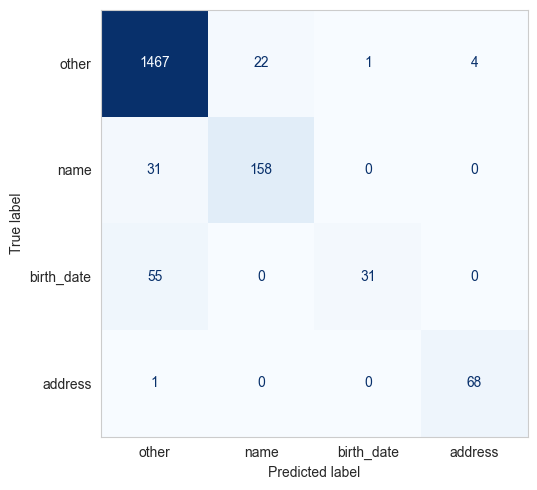

In [23]:
# Menggunakan variabel dari iterasi Fold terakhir
df_test_last = df_triage_test.copy()
df_seg_test_last = df_seg_test.copy()

avail_seg_feat = [f for f in FEATURE_COLS if f in df_seg_test_last.columns]
X_seg_last     = df_seg_test_last[avail_seg_feat].fillna(0)
y_true_last    = df_seg_test_last['label'].map(LABEL_MAP)
y_pred_last    = field_clf.predict(X_seg_last)

print("\nLaporan Akurasi Klasifikasi Teks Terakhir:")
print(classification_report(y_true_last, y_pred_last, target_names=['other','name','birth_date','address']))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true_last, y_pred_last)
ConfusionMatrixDisplay(cm, display_labels=['other','name','birth_date','address']).plot(ax=ax, colorbar=False, cmap='Blues')
plt.grid(False)
plt.tight_layout()
plt.show()

## Mengukur Pentingnya Fitur dengan SHAP
Blok ini mencari tahu data numerik apa yang diprioritaskan oleh model Machine Learning untuk setiap prediksi kelas.
Kita memastikan bahwa keputusan yang diambil model sesuai dengan akal sehat dan tidak terpaku pada angka angka secara kebetulan belaka.

In [24]:
df_seg_test_last['pred_label_str'] = [INV_LABEL_MAP[p] for p in y_pred_last]

explainer   = shap.TreeExplainer(field_clf)
shap_values = explainer.shap_values(X_seg_last)

CLASS_NAMES = ['other', 'name', 'birth_date', 'address']
for class_idx, class_name in enumerate(CLASS_NAMES):
    if class_name == 'other':
        continue
    plt.figure(figsize=(10, 5))
    sv = shap_values[class_idx]
    if len(sv.shape) == 2 and sv.shape[1] == X_seg_last.shape[1] + 1:
        sv = sv[:, :-1]

    shap.summary_plot(
        sv,
        X_seg_last,
        feature_names=avail_seg_feat,
        show=False,
        plot_type='bar',
    )
    plt.title(f"Bobot Fitur Klasifikasi: {class_name.upper()}", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(DATASET_DIR, f'shap_{class_name}.png'), dpi=100)
    plt.show()

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1000x500 with 0 Axes>

## Menggambar Ulang Garis Pemotongan
Blok ini menampilkan ilustrasi KTP beserta hasil bacaan klasifikasinya yang digambar kotak warna warni di sekeliling teks.
Kita butuh meninjau kembali gambar ini agar tidak hanya berasumsi berdasar angka tabel tapi bisa melihat apakah titik lokasinya sudah akurat secara visual.

In [ ]:
import ast
VIS_OUT_DIR = os.path.join(DATASET_DIR, 'semantic_visualizations')
os.makedirs(VIS_OUT_DIR, exist_ok=True)

sample_files = list(df_test_last['filename'].head(5))

for fname in sample_files:
    img_path = os.path.join(CROPPED_DIR, fname)
    img      = cv2.imread(img_path)
    if img is None:
        continue

    segments = df_seg_test_last[df_seg_test_last['filename'] == fname]
    for _, seg in segments.iterrows():
        pred_str = seg['pred_label_str']
        if pred_str == 'other':
            continue

        try:
            box = ast.literal_eval(str(seg['box']))
        except:
            continue
        if not box:
            continue

        color = COLOR_MAP[pred_str]
        pts   = np.array(box, np.int32).reshape((-1, 1, 2))
        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)

        x_min = int(np.min(pts[:, 0, 0]))
        y_min = int(np.min(pts[:, 0, 1]))
        cv2.putText(img, pred_str.upper(), (x_min, max(y_min - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 2)

    out_path = os.path.join(VIS_OUT_DIR, f"semantic_{fname}")
    cv2.imwrite(out_path, img)

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Menyimpan Laporan ke Dokumen
Blok ini menuliskan semua hasil angka akurasi ke dalam dokumen dan mencetak ulang ringkasan metrik secara ringkas di layar.
Kita wajib menyimpannya sebagai fail fisik supaya hasil eksekusi ini kelak bisa dibagikan dan tidak hilang saat aplikasi ditutup.

In [ ]:
all_metrics_df.to_csv(os.path.join(DATASET_DIR, 'evaluation_results.csv'), index=False)

print("Semua proses rampung.")
print(f"  evaluation_results.csv : {len(all_metrics_df)} rekam data")
print(f"  Metrik STP Rate Final  : {stp_rate:.1%}")